In [42]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter, defaultdict

sns.set_style("whitegrid")

### Загрузка датасетов и вывод структуры

In [43]:
with open('../data/steamUsersDataset.json', encoding='utf-8') as file:
    steamUsersDataset = json.load(file)

with open('../data/steamGamesDataset.json', encoding='utf-8') as file:
    steamGamesDataset = json.load(file)

totalUsersCount = len(steamUsersDataset)
totalGamesInGamesDataset = len(steamGamesDataset)

print(f"Общее количество записей в steamUsersDataset: {totalUsersCount}")
print(f"Общее количество записей в steamGamesDataset: {totalGamesInGamesDataset}")

if steamUsersDataset:
    firstUser = steamUsersDataset[0]
    userKeys = list(firstUser.keys())
    print(f"Ключи в записи пользователя: {userKeys}")
    if 'ownedGames' in firstUser and firstUser['ownedGames']:
        print(f"Пример ключей в игре пользователя: {list(firstUser['ownedGames'][0].keys())}")

if steamGamesDataset:
    firstGame = steamGamesDataset[0]
    gameKeys = list(firstGame.keys())
    print(f"Ключи в записи игры: {gameKeys}")

Общее количество записей в steamUsersDataset: 20000
Общее количество записей в steamGamesDataset: 26072
Ключи в записи пользователя: ['steamId', 'gameCount', 'ownedGames', 'error', 'personaname', 'communityvisibilitystate', 'timecreated', 'loccountrycode']
Пример ключей в игре пользователя: ['appid', 'name', 'playtimeForever']
Ключи в записи игры: ['appid', 'name', 'positive', 'negative', 'owners', 'averageForever', 'medianForever', 'languages', 'genre', 'tags']


### Фильтрация приватных профилей / ошибок

In [44]:
filteredSteamUsersDataset = []
privateOrErrorProfilesCount = 0

for user in steamUsersDataset:
    errorFlag = user.get('error')
    if errorFlag:
        privateOrErrorProfilesCount += 1
    else:
        filteredSteamUsersDataset.append(user)

publicUsersCount = len(filteredSteamUsersDataset)
print(f"Приватных/ошибочных профилей (выкинуто): {privateOrErrorProfilesCount} ({privateOrErrorProfilesCount / totalUsersCount * 100:.1f}%)")
print(f"Публичных профилей для анализа: {publicUsersCount}")

Приватных/ошибочных профилей (выкинуто): 10022 (50.1%)
Публичных профилей для анализа: 9978


### Базовая статистика по отфильтрованным пользователям

In [45]:
userBasicData = []
for user in filteredSteamUsersDataset:
    ownedGamesCount = len(user.get('ownedGames', []))
    userBasicData.append({
        'steamId': user.get('steamId'),
        'profileName': user.get('profileName'),
        'numberOfOwnedGames': ownedGamesCount
    })

usersDataFrame = pd.DataFrame(userBasicData)

print("Основная статистика по публичным пользователям:")
print(usersDataFrame.describe())

usersDataFrame.to_csv('../data/userBasicStatistics.csv', index=False)
print("Базовая статистика сохранена в data/userBasicStatistics.csv")

Основная статистика по публичным пользователям:
       numberOfOwnedGames
count         9978.000000
mean            82.779816
std            167.506877
min              1.000000
25%             14.000000
50%             40.000000
75%             95.000000
max           4721.000000
Базовая статистика сохранена в data/userBasicStatistics.csv


### Распределение количества игр у пользователей

Среднее количество игр у пользователя: 82.8
Медиана: 40.0


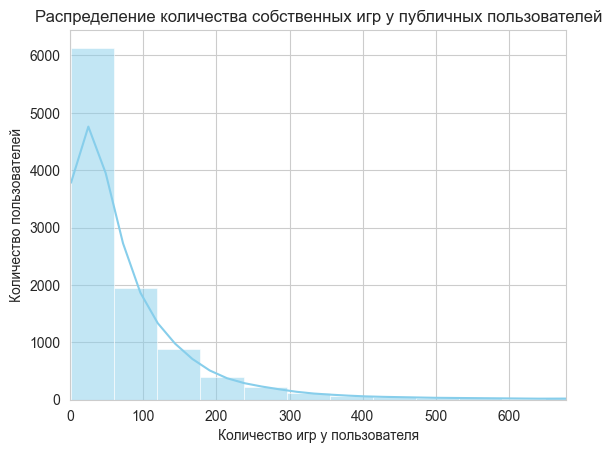

In [46]:
plt.figure()
sns.histplot(usersDataFrame['numberOfOwnedGames'], kde=True, bins=80, color='skyblue')
plt.title('Распределение количества собственных игр у публичных пользователей')
plt.xlabel('Количество игр у пользователя')
plt.ylabel('Количество пользователей')
plt.xlim(0, usersDataFrame['numberOfOwnedGames'].quantile(0.99))

print(f"Среднее количество игр у пользователя: {usersDataFrame['numberOfOwnedGames'].mean():.1f}")
print(f"Медиана: {usersDataFrame['numberOfOwnedGames'].median()}")

### Топ самых популярных игр

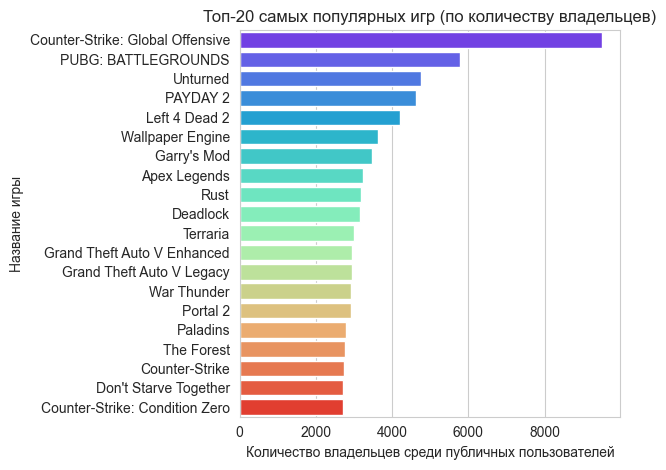

In [47]:
topNumber = 20

allOwnedAppIds = []
for user in filteredSteamUsersDataset:
    for game in user.get('ownedGames', []):
        allOwnedAppIds.append(game.get('appid'))

gameOwnershipCounter = Counter(allOwnedAppIds)
topTenGames = gameOwnershipCounter.most_common(topNumber)

topGameIds = [game[0] for game in topTenGames]
topGameCounts = [game[1] for game in topTenGames]

gameNamesMap = {game.get('appid'): game.get('name', f'AppID_{game.get("appid")}') for game in steamGamesDataset}
topGameNames = [gameNamesMap.get(appId, f'AppID_{appId}') for appId in topGameIds]

plt.figure()
sns.barplot(x=topGameCounts, y=topGameNames, hue=topGameNames, palette='rainbow')
plt.title(f'Топ-{topNumber} самых популярных игр (по количеству владельцев)')
plt.xlabel('Количество владельцев среди публичных пользователей')
plt.ylabel('Название игры')
plt.tight_layout()
plt.show()

### Распределение времени игры

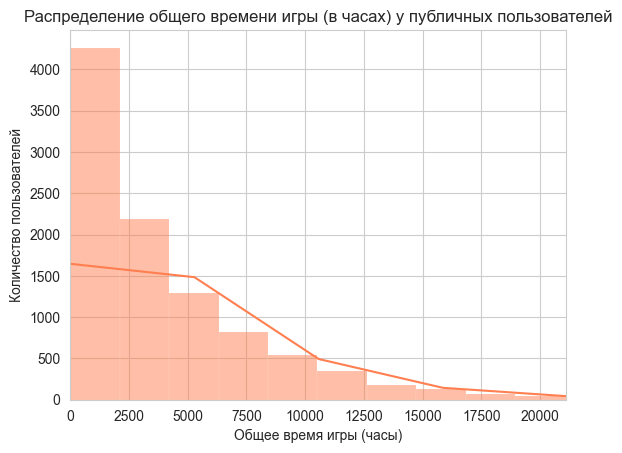

Среднее время игры на пользователя: 4475.8 часов


In [60]:
totalPlaytimePerUser = []
hasPlaytimeData = False

for user in filteredSteamUsersDataset:
    userTotalPlaytime = 0
    for game in user.get('ownedGames', []):
        playtime = game.get('playtimeForever') or 0
        if playtime > 0:
            hasPlaytimeData = True
        userTotalPlaytime += playtime
    totalPlaytimePerUser.append(userTotalPlaytime / 60)

if hasPlaytimeData:
    playtimeDataFrame = pd.DataFrame({'totalPlaytimeHours': totalPlaytimePerUser})
    plt.figure()
    sns.histplot(playtimeDataFrame['totalPlaytimeHours'], kde=True, bins=500, color='coral')
    plt.title('Распределение общего времени игры (в часах) у публичных пользователей')
    plt.xlabel('Общее время игры (часы)')
    plt.ylabel('Количество пользователей')
    plt.xlim(0, playtimeDataFrame['totalPlaytimeHours'].quantile(0.99))
    plt.show()
    
    print(f"Среднее время игры на пользователя: {playtimeDataFrame['totalPlaytimeHours'].mean():.1f} часов")
else:
    print("В данных пользователей не обнаружено поля playtimeForever")

### Информация и графики по датасету игр

Всего уникальных игр в steamGamesDataset: 26072


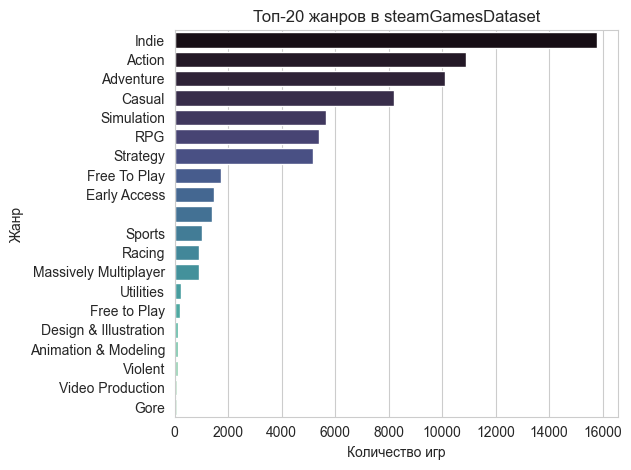

Игр из steamGamesDataset, которые встречаются у пользователей: 26072 (100.0%)


In [49]:
print(f"Всего уникальных игр в steamGamesDataset: {totalGamesInGamesDataset}")

topNumber = 20

allGenres = []
for game in steamGamesDataset:
    genres = game.get('genre')

    if isinstance(genres, str):
        splitGenres = [genre.strip() for genre in genres.split(',')]
        allGenres.extend(splitGenres)
    elif isinstance(genres, list):
        allGenres.extend(genres)

genreCounter = Counter(allGenres)
topGenres = genreCounter.most_common(topNumber)

genreNames = [genre[0] for genre in topGenres]
genreCounts = [genre[1] for genre in topGenres]
    
plt.figure()
sns.barplot(x=genreCounts, y=genreNames, hue=genreNames, palette='mako')
plt.title(f'Топ-{topNumber} жанров в steamGamesDataset')
plt.xlabel('Количество игр')
plt.ylabel('Жанр')
plt.tight_layout()
plt.show()

ownedAppIdsSet = set(allOwnedAppIds)
gamesInDatasetAppIds = {game.get('appid') for game in steamGamesDataset}
coveredGamesCount = len(ownedAppIdsSet & gamesInDatasetAppIds)

print(f"Игр из steamGamesDataset, которые встречаются у пользователей: {coveredGamesCount} ({coveredGamesCount / totalGamesInGamesDataset * 100:.1f}%)")

### Подготовка данных по времени игры

In [50]:
gamePlaytimesDict = defaultdict(list)

for user in filteredSteamUsersDataset:
    for ownedGame in user.get('ownedGames', []):
        appid = ownedGame.get('appid')
        playtimeMinutes = ownedGame.get('playtimeForever', 0)
        if playtimeMinutes > 0:
            playtimeHours = playtimeMinutes / 60.0
            gamePlaytimesDict[appid].append(playtimeHours)

gamePlaytimeData = []
gameNamesMap = {game.get('appid'): game.get('name', f'AppID_{game.get("appid")}') for game in steamGamesDataset}

for appid, playtimesList in gamePlaytimesDict.items():
    if playtimesList:
        gameName = gameNamesMap.get(appid, f'AppID_{appid}')
        gamePlaytimeData.append({
            'gameName': gameName,
            'appid': appid,
            'playtimeHoursList': playtimesList,
            'medianPlaytimeHours': np.median(playtimesList),
            'meanPlaytimeHours': np.mean(playtimesList),
            'totalPlaytimeHours': sum(playtimesList)
        })

gamePlaytimeDataFrame = pd.DataFrame(gamePlaytimeData)
print(f"Игр с ненулевым временем игры среди пользователей: {len(gamePlaytimeDataFrame)}")

Игр с ненулевым временем игры среди пользователей: 21216


### Топ самых играемых игр по общему времени

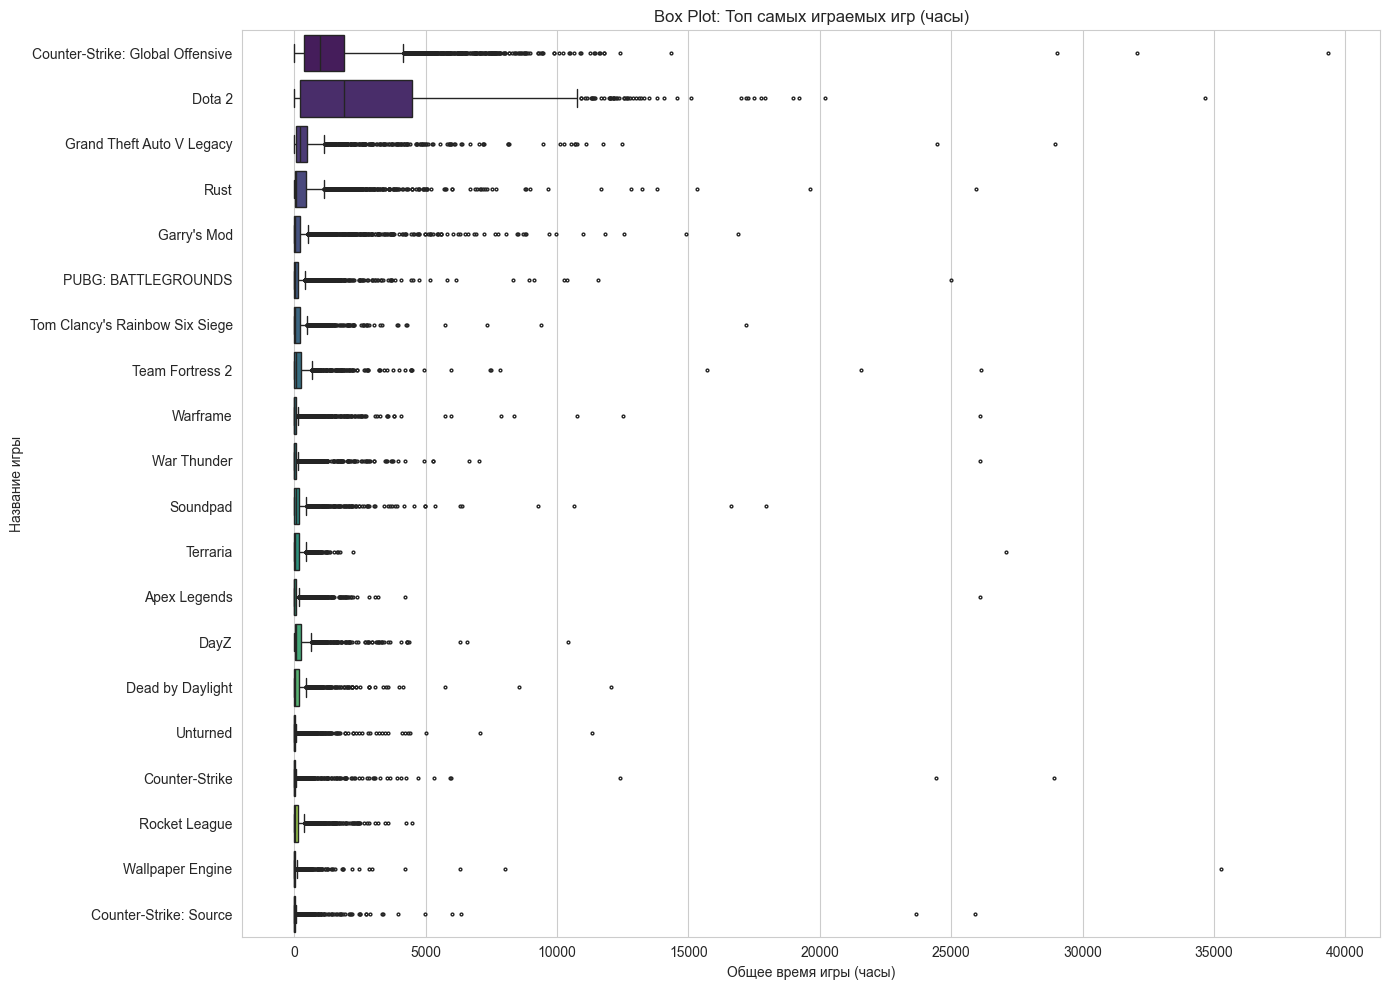

Топ игр по общему времени игры:
                             gameName  totalPlaytimeHours  medianPlaytimeHours
2    Counter-Strike: Global Offensive        1.232704e+07           976.600000
416                            Dota 2        6.180983e+06          1911.283333
699         Grand Theft Auto V Legacy        1.463513e+06           206.600000
6                                Rust        1.427501e+06            89.058333
39                        Garry's Mod        1.144099e+06            42.516667
13                PUBG: BATTLEGROUNDS        1.022800e+06            27.316667
226    Tom Clancy's Rainbow Six Siege        5.029605e+05            47.266667
35                    Team Fortress 2        4.539440e+05            63.875000
744                          Warframe        4.476821e+05            10.316667
696                       War Thunder        4.325109e+05             9.983333
501                          Soundpad        3.994015e+05            53.100000
3                   

In [51]:
topNumber = len(topGameNames)
topPlayedGames = gamePlaytimeDataFrame.nlargest(topNumber, 'totalPlaytimeHours')

boxPlotData = []
for _, row in topPlayedGames.iterrows():
    for hours in row['playtimeHoursList']:
        boxPlotData.append({'gameName': row['gameName'], 'playtimeHours': hours})

boxPlotDataFrame = pd.DataFrame(boxPlotData)

plt.figure(figsize=(14, 10))
sns.boxplot(data=boxPlotDataFrame, x='playtimeHours', y='gameName', hue='gameName', palette='viridis', fliersize=2)
plt.title('Box Plot: Топ самых играемых игр (часы)')
plt.xlabel('Общее время игры (часы)')
plt.ylabel('Название игры')
plt.tight_layout()
plt.show()

print("Топ игр по общему времени игры:")
print(topPlayedGames[['gameName', 'totalPlaytimeHours', 'medianPlaytimeHours']].head(topNumber))

### Распределение процента положительных отзывов в датасете игр

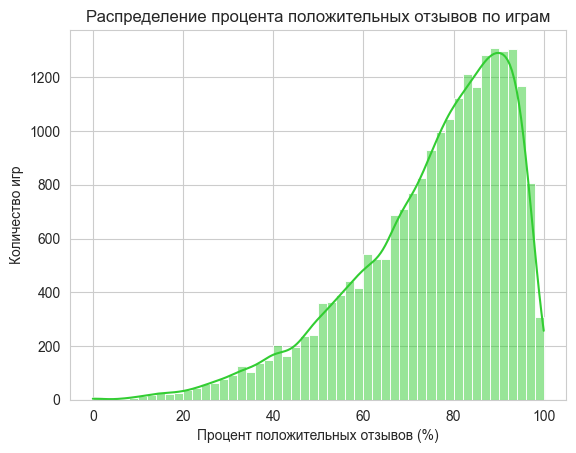

Средний процент положительных отзывов: 75.49%
Медиана: 79.38%


In [52]:
positivePercentageList = []
totalReviewsList = []

for game in steamGamesDataset:
    positive = game.get('positive', 0)
    negative = game.get('negative', 0)
    totalReviews = positive + negative
    if totalReviews > 0:
        positivePercentage = (positive / totalReviews) * 100
        positivePercentageList.append(positivePercentage)
        totalReviewsList.append(totalReviews)

positivePercentageDataFrame = pd.DataFrame({
    'positivePercentage': positivePercentageList,
    'totalReviews': totalReviewsList
})

plt.figure()
sns.histplot(positivePercentageDataFrame['positivePercentage'], kde=True, bins=50, color='limegreen')
plt.title('Распределение процента положительных отзывов по играм')
plt.xlabel('Процент положительных отзывов (%)')
plt.ylabel('Количество игр')
plt.show()

print(f"Средний процент положительных отзывов: {positivePercentageDataFrame['positivePercentage'].mean():.2f}%")
print(f"Медиана: {positivePercentageDataFrame['positivePercentage'].median():.2f}%")

### Топ игр по количеству отзывов (positive + negative)

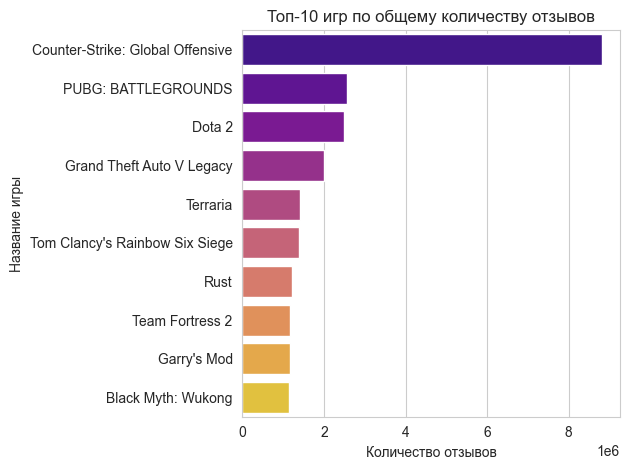

In [53]:
topNumber = 10

gameReviewsData = []
for game in steamGamesDataset:
    positive = game.get('positive', 0)
    negative = game.get('negative', 0)
    totalReviews = positive + negative
    if totalReviews > 0:
        gameReviewsData.append({
            'gameName': game.get('name', f'AppID_{game.get("appid")}'),
            'totalReviews': totalReviews,
            'positivePercentage': (positive / totalReviews) * 100 if totalReviews > 0 else 0
        })

gameReviewsDataFrame = pd.DataFrame(gameReviewsData)
topTenReviewedGames = gameReviewsDataFrame.nlargest(topNumber, 'totalReviews')

plt.figure()
sns.barplot(data=topTenReviewedGames, x='totalReviews', y='gameName', hue='gameName', palette='plasma')
plt.title(f'Топ-{topNumber} игр по общему количеству отзывов')
plt.xlabel('Количество отзывов')
plt.ylabel('Название игры')
plt.tight_layout()
plt.show()

### Абсолютные веса тегов

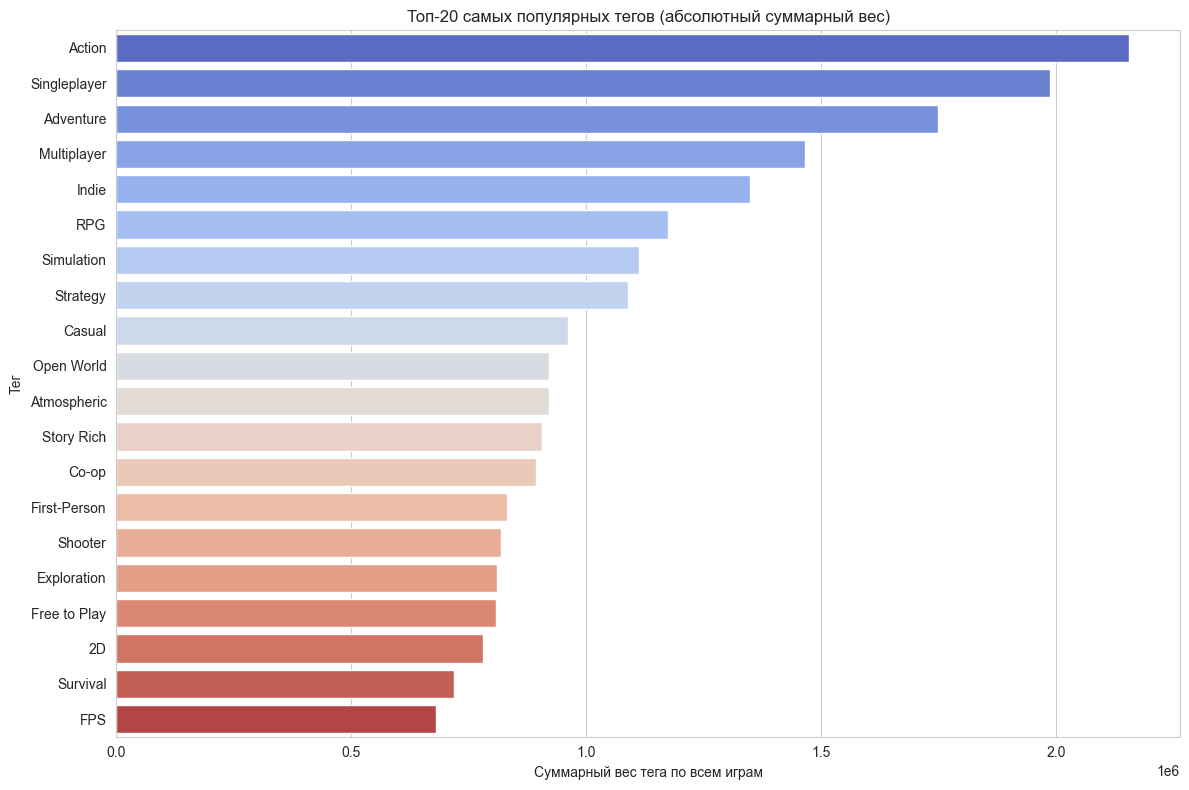

In [54]:
topNumber = 20

allTagsCounterAbsolute = Counter()

for game in steamGamesDataset:
    tagsDict = game.get('tags', {})
    if isinstance(tagsDict, dict):
        for tagName, tagWeight in tagsDict.items():
            allTagsCounterAbsolute[tagName] += tagWeight

topTwentyTagsAbsolute = allTagsCounterAbsolute.most_common(topNumber)
tagNamesAbsolute = [tag[0] for tag in topTwentyTagsAbsolute]
tagWeightsAbsolute = [tag[1] for tag in topTwentyTagsAbsolute]

plt.figure(figsize=(12, 8))
sns.barplot(x=tagWeightsAbsolute, y=tagNamesAbsolute, hue=tagNamesAbsolute, palette='coolwarm', legend=False)
plt.title(f'Топ-{topNumber} самых популярных тегов (абсолютный суммарный вес)')
plt.xlabel('Суммарный вес тега по всем играм')
plt.ylabel('Тег')
plt.tight_layout()
plt.show()

### Нормированные веса тегов

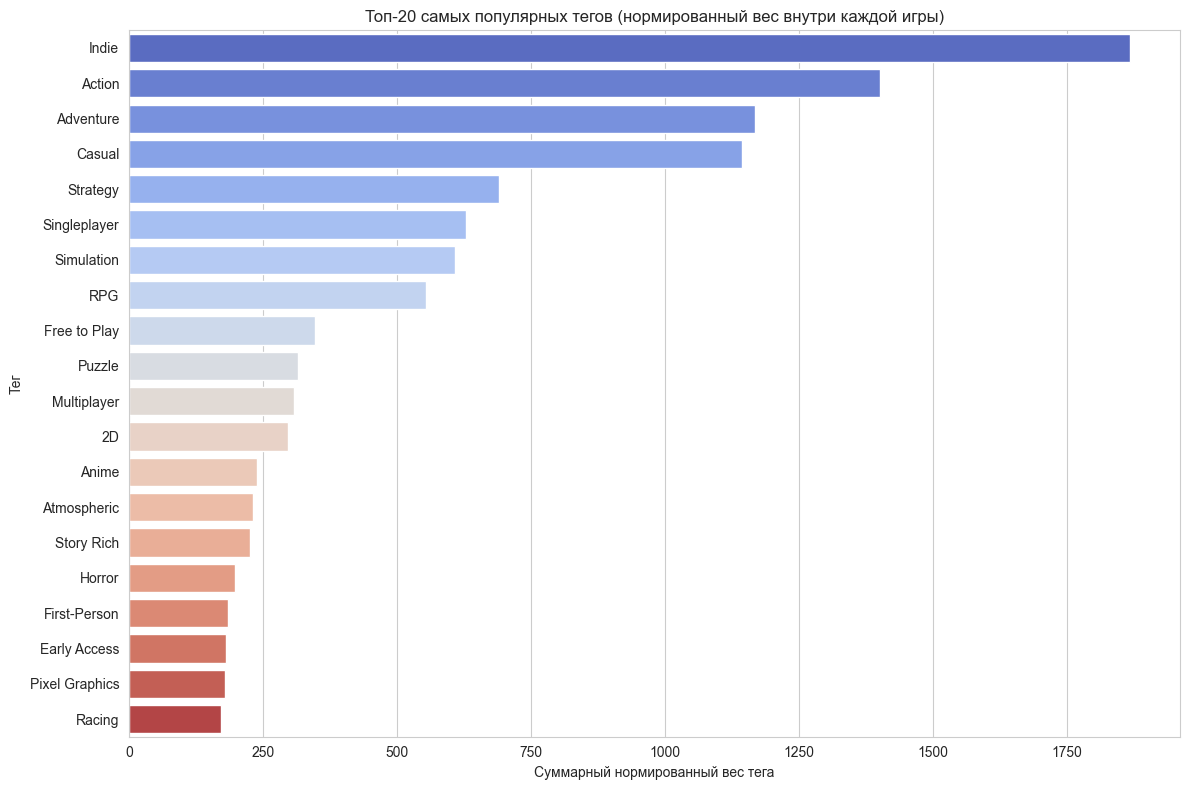

In [55]:
allTagsCounterNormalized = Counter()

for game in steamGamesDataset:
    tagsDict = game.get('tags', {})
    if isinstance(tagsDict, dict) and tagsDict:
        totalWeightInGame = sum(tagsDict.values())
        if totalWeightInGame > 0:
            for tagName, tagWeight in tagsDict.items():
                normalizedWeight = tagWeight / totalWeightInGame
                allTagsCounterNormalized[tagName] += normalizedWeight

topTwentyTagsNormalized = allTagsCounterNormalized.most_common(topNumber)
tagNamesNormalized = [tag[0] for tag in topTwentyTagsNormalized]
tagWeightsNormalized = [tag[1] for tag in topTwentyTagsNormalized]

plt.figure(figsize=(12, 8))
sns.barplot(x=tagWeightsNormalized, y=tagNamesNormalized, hue=tagNamesNormalized, palette='coolwarm', legend=False)
plt.title(f'Топ-{topNumber} самых популярных тегов (нормированный вес внутри каждой игры)')
plt.xlabel('Суммарный нормированный вес тега')
plt.ylabel('Тег')
plt.tight_layout()
plt.show()

### Категории владельцев игр (owners)

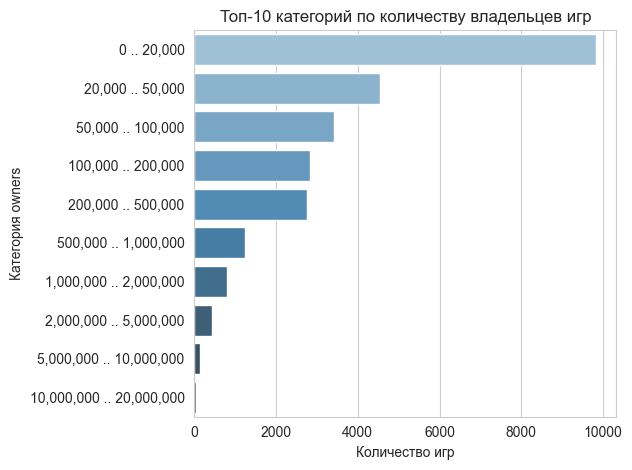

In [56]:
topNumber = 10

ownerCategoriesCounter = Counter()

for game in steamGamesDataset:
    ownersStr = game.get('owners', '')
    if ownersStr:
        category = ownersStr.strip()
        ownerCategoriesCounter[category] += 1

ownerCategoriesDataFrame = pd.DataFrame({
    'ownerCategory': list(ownerCategoriesCounter.keys()),
    'gameCount': list(ownerCategoriesCounter.values())
}).sort_values('gameCount', ascending=False)

plt.figure()
sns.barplot(data=ownerCategoriesDataFrame.head(topNumber), x='gameCount', y='ownerCategory', hue='ownerCategory', palette='Blues_d')
plt.title('Топ-10 категорий по количеству владельцев игр')
plt.xlabel('Количество игр')
plt.ylabel('Категория owners')
plt.tight_layout()
plt.show()

### Поддержка языков

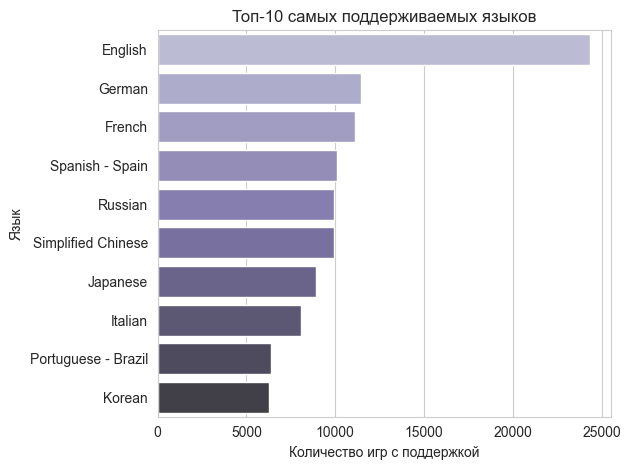

In [57]:
topNumber = 10

allLanguagesCounter = Counter()
for game in steamGamesDataset:
    languagesStr = game.get('languages', '')
    if isinstance(languagesStr, str) and languagesStr:
        langs = [lang.strip() for lang in languagesStr.split(',')]
        for lang in langs:
            allLanguagesCounter[lang] += 1

topLanguages = allLanguagesCounter.most_common(topNumber)
langNames = [lang[0] for lang in topLanguages]
langCounts = [lang[1] for lang in topLanguages]

plt.figure()
sns.barplot(x=langCounts, y=langNames, hue=langNames, palette='Purples_d')
plt.title(f'Топ-{topNumber} самых поддерживаемых языков')
plt.xlabel('Количество игр с поддержкой')
plt.ylabel('Язык')
plt.tight_layout()
plt.show()

### Анализ пользователей - страны и год создания аккаунта

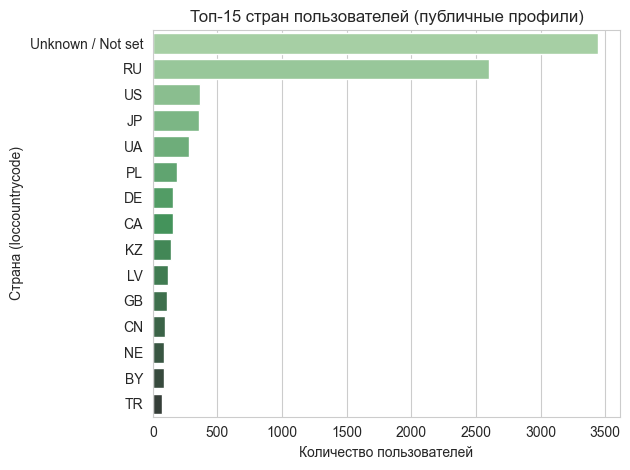

In [58]:
topNumber = 15

countryCounter = Counter()
for user in filteredSteamUsersDataset:
    country = user.get('loccountrycode')
    if not country:
        country = 'Unknown / Not set'
    countryCounter[country] += 1

topCountriesDataFrame = pd.DataFrame({
    'country': list(countryCounter.keys()),
    'userCount': list(countryCounter.values())
}).sort_values('userCount', ascending=False).head(topNumber)

plt.figure()
sns.barplot(data=topCountriesDataFrame, x='userCount', y='country', hue='country', palette='Greens_d')
plt.title(f'Топ-{topNumber} стран пользователей (публичные профили)')
plt.xlabel('Количество пользователей')
plt.ylabel('Страна (loccountrycode)')
plt.tight_layout()
plt.show()



### Распределение года создания аккаунтов

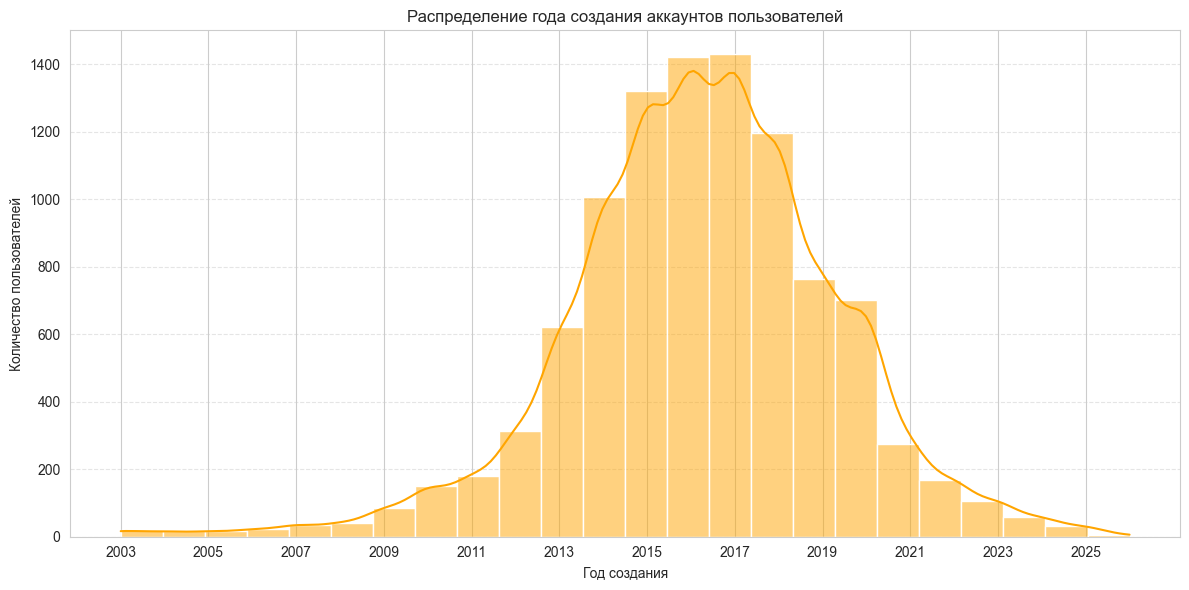

Средний год создания аккаунта: 2016.3
Диапазон лет: 2003 — 2026


In [59]:
creationYears = []
for user in filteredSteamUsersDataset:
    timestamp = user.get('timecreated')
    if timestamp:
        year = pd.to_datetime(timestamp, unit='s').year
        creationYears.append(year)

creationYearsDataFrame = pd.DataFrame({'creationYear': creationYears})

minYear = creationYearsDataFrame['creationYear'].min()
maxYear = creationYearsDataFrame['creationYear'].max()
numberOfBins = maxYear - minYear + 1

plt.figure(figsize=(12, 6))
sns.histplot(
    data=creationYearsDataFrame,
    x='creationYear',
    bins=numberOfBins,
    color='orange',
    kde=True,
    stat='count'
)
plt.title('Распределение года создания аккаунтов пользователей')
plt.xlabel('Год создания')
plt.ylabel('Количество пользователей')
plt.xticks(range(minYear, maxYear + 1, 2))
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Средний год создания аккаунта: {creationYearsDataFrame['creationYear'].mean():.1f}")
print(f"Диапазон лет: {minYear} — {maxYear}")